In [1]:
# importing libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# loading the dataset

df = pd.read_csv('/home/ishanmohanty4/Desktop/Downloads/Bengaluru_House_Data.csv')
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
# no of rows and cols in the dataset
df.shape

(13320, 9)

In [4]:
# Columns in dataset

df.columns


Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='str')

In [5]:
# Description of dataset

df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [6]:
# Info of dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


In [7]:
# looking for null values and cleaning the data

df[df['location'].isnull()]
df[df['size'].isnull()]
df['balcony'] = df['balcony'].fillna(df['balcony'].median())

In [8]:
df['bath'] = df['bath'].fillna(df.groupby(by = 'size')['bath'].median())

In [9]:
df['society'] = df['society'].notnull().astype('int')

In [10]:
df.sample(10)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
10992,Super built-up Area,Ready To Move,Kuvempu Nagar,3 BHK,1,1540,3.0,2.0,150.00
11064,Super built-up Area,Ready To Move,Kallumantapa,2 BHK,1,1255,2.0,3.0,65.00
4512,Super built-up Area,Ready To Move,Ardendale,3 BHK,1,1732.46,3.0,2.0,92.00
826,Super built-up Area,Ready To Move,Panathur,3 BHK,0,1695,3.0,1.0,90.00
101,Built-up Area,Ready To Move,Chandapura,2 BHK,1,650,1.0,1.0,17.00
10907,Carpet Area,Ready To Move,KR Puram,2 BHK,1,866.28,2.0,0.0,36.38
11993,Super built-up Area,18-Apr,Whitefield,3 BHK,1,1396,3.0,1.0,74.00
2560,Plot Area,Ready To Move,BCC Layout,4 Bedroom,0,1500,5.0,1.0,230.00
12628,Built-up Area,Ready To Move,Shree Ananth Nagar Layout,2 BHK,1,1154,2.0,1.0,57.00
10240,Plot Area,Ready To Move,Jalahalli,1 Bedroom,0,600,1.0,0.0,37.00


In [11]:
df['society'] == 0

0        False
1        False
2         True
3        False
4         True
         ...  
13315    False
13316     True
13317    False
13318    False
13319     True
Name: society, Length: 13320, dtype: bool

In [12]:
# percent of missing value in society column
(df['society'].isnull().sum()/df.shape[0])*100

np.float64(0.0)

In [13]:
# extracting no. for bhk

df['size'] = df['size'].str.split().str.get(0)

In [14]:
df.sample(10)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
5194,Super built-up Area,Ready To Move,Begur Road,3,1,1410,2.0,3.0,53.58
12478,Super built-up Area,Ready To Move,Parappana Agrahara,2,0,1194,2.0,2.0,46.00
12117,Super built-up Area,Ready To Move,Thubarahalli,3,1,1885,3.0,2.0,85.52
1910,Super built-up Area,Ready To Move,Electronic City,2,1,1128,2.0,1.0,64.00
6757,Super built-up Area,Ready To Move,Jakkur,2,1,1230,2.0,1.0,79.00
8106,Plot Area,Ready To Move,Wilson Garden,8,0,1850,12.0,2.0,300.00
3738,Carpet Area,Ready To Move,Lingarajapuram,2,1,1203,2.0,1.0,59.86
13121,Super built-up Area,19-Sep,Kudlu Gate,3,1,1432,2.0,2.0,61.11
5678,Super built-up Area,Ready To Move,Bhoganhalli,3,1,1760,3.0,2.0,127.00
1078,Plot Area,Ready To Move,BTM 1st Stage,9,1,3300,14.0,2.0,500.00


In [15]:
# cleaning total_sqft col

def convert_sqft_to_num(x):
    tokens = str(x).split('-')
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)
df = df.dropna(subset = ['total_sqft'])

In [16]:
# Feature Engineering

df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']

In [17]:
df.head(10)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2,1,1056.0,2.0,1.0,39.07,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,4,1,2600.0,5.0,3.0,120.00,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,3,0,1440.0,2.0,3.0,62.00,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,1,1521.0,3.0,1.0,95.00,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,2,0,1200.0,2.0,1.0,51.00,4250.000000
5,Super built-up Area,Ready To Move,Whitefield,2,1,1170.0,2.0,1.0,38.00,3247.863248
6,Super built-up Area,18-May,Old Airport Road,4,1,2732.0,4.0,2.0,204.00,7467.057101
7,Super built-up Area,Ready To Move,Rajaji Nagar,4,1,3300.0,4.0,2.0,600.00,18181.818182
8,Super built-up Area,Ready To Move,Marathahalli,3,0,1310.0,3.0,1.0,63.25,4828.244275
9,Plot Area,Ready To Move,Gandhi Bazar,6,0,1020.0,6.0,2.0,370.00,36274.509804


In [18]:
df['size'] = df['size'].astype('float')
df['size_bath_ratio'] = df['size'] / df['bath']

In [19]:
df.head(10)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,price_per_sqft,size_bath_ratio
0,Super built-up Area,19-Dec,Electronic City Phase II,2.0,1,1056.0,2.0,1.0,39.07,3699.810606,1.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4.0,1,2600.0,5.0,3.0,120.00,4615.384615,0.8
2,Built-up Area,Ready To Move,Uttarahalli,3.0,0,1440.0,2.0,3.0,62.00,4305.555556,1.5
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3.0,1,1521.0,3.0,1.0,95.00,6245.890861,1.0
4,Super built-up Area,Ready To Move,Kothanur,2.0,0,1200.0,2.0,1.0,51.00,4250.000000,1.0
5,Super built-up Area,Ready To Move,Whitefield,2.0,1,1170.0,2.0,1.0,38.00,3247.863248,1.0
6,Super built-up Area,18-May,Old Airport Road,4.0,1,2732.0,4.0,2.0,204.00,7467.057101,1.0
7,Super built-up Area,Ready To Move,Rajaji Nagar,4.0,1,3300.0,4.0,2.0,600.00,18181.818182,1.0
8,Super built-up Area,Ready To Move,Marathahalli,3.0,0,1310.0,3.0,1.0,63.25,4828.244275,1.0
9,Plot Area,Ready To Move,Gandhi Bazar,6.0,0,1020.0,6.0,2.0,370.00,36274.509804,1.0


In [20]:
# removing square feet per size outliers

df['total_sqft'] = df['total_sqft'].fillna(0)
df1 = df[df['total_sqft'] / df['size'] >= 300].copy()

In [21]:
# Grouping rare locations (<=10 entries) to stabilize group statistics
# ---------------------------------------------------------
df1['location'] = df1['location'].astype(str).str.strip()
location_stats = df1['location'].value_counts()
other_locations = location_stats[location_stats <= 10].index
df1['location'] = df1['location'].apply(lambda x: 'other' if x in other_locations else x)

In [22]:
# Retain properties within mean +/- 1 standard deviation per location

def remove_pps_outliers(data):
    df_out = pd.DataFrame()
    for location, subdf in data.groupby('location'):
        mean = np.mean(subdf['price_per_sqft'])
        std = np.std(subdf['price_per_sqft'])
        reduced_df = subdf[(subdf['price_per_sqft'] > (mean - std)) & 
                           (subdf['price_per_sqft'] <= (mean + std))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

df2 = remove_pps_outliers(df1)

In [23]:
# Remove (N) size apartments cheaper per sqft than (N-1) size apartments in the same area

def remove_size_outliers(data):
    exclude_indices = np.array([])
    for location, location_df in data.groupby('location'):
        size_stats = {}
        for size, size_df in location_df.groupby('size'):
            size_stats[size] = {
                'mean': np.mean(size_df['price_per_sqft']),
                'count': size_df.shape[0]
            }
        for size, size_df in location_df.groupby('size'):
            stats = size_stats.get(size - 1)
            if stats and stats['count'] > 5:
                exclude_indices = np.append(
                    exclude_indices, 
                    size_df[size_df['price_per_sqft'] < stats['mean']].index.values
                )
    return data.drop(exclude_indices, axis='index')

df3 = remove_size_outliers(df2)

In [24]:
# removing bathroom outliers

df_clean = df3[df3['bath'] <= df3['size'] + 2]

Text(0.5, 1.0, 'Distribution of House Prices')

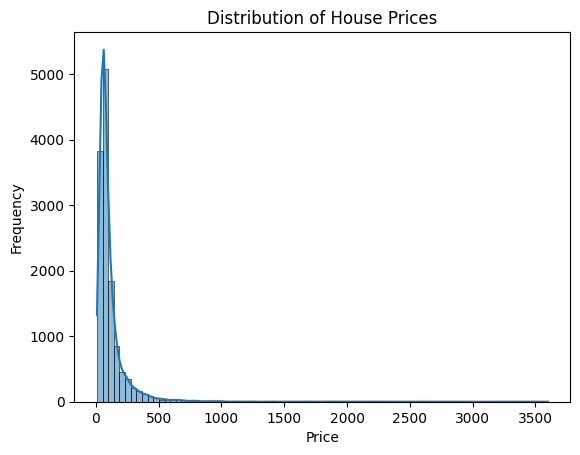

In [25]:
# EDA

sns.histplot(data = df, x = 'price', kde = True, bins = 80)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of House Prices')

In [26]:
df['price'].skew()

np.float64(8.075232426869087)

(0.0, 500.0)

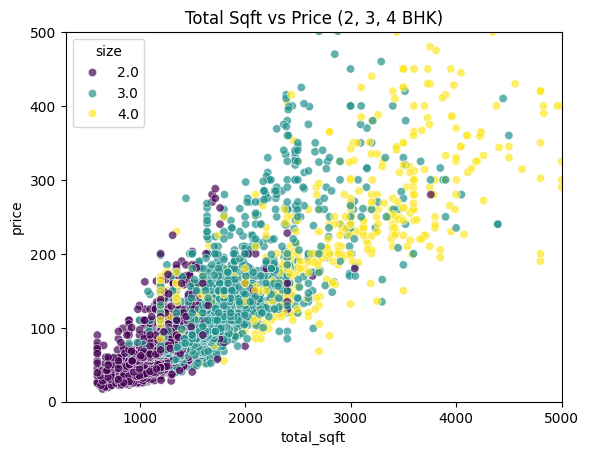

In [27]:
sns.scatterplot(data = df_clean[df_clean['size'].isin([2,3,4])],
                x = 'total_sqft', 
                y = 'price',
                hue = 'size',
                palette = 'viridis',
                alpha = 0.7
                )

plt.title('Total Sqft vs Price (2, 3, 4 BHK)')
plt.xlim(300, 5000)
plt.ylim(0,500)

Text(0.5, 1.0, 'Feature Correlation Matrix')

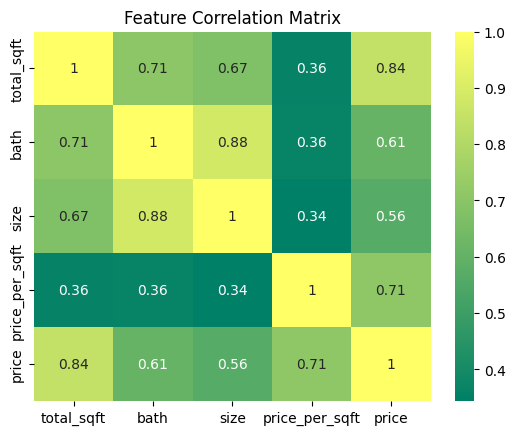

In [28]:
numeric_cols = ['total_sqft', 'bath', 'size', 'price_per_sqft', 'price']
sns.heatmap(df_clean[numeric_cols].corr(), annot = True, cmap = 'summer')
plt.title('Feature Correlation Matrix')

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'other'),
  Text(1, 0, 'Whitefield'),
  Text(2, 0, 'Sarjapur  Road'),
  Text(3, 0, 'Electronic City'),
  Text(4, 0, 'Raja Rajeshwari Nagar'),
  Text(5, 0, 'Uttarahalli'),
  Text(6, 0, 'Haralur Road'),
  Text(7, 0, 'Marathahalli'),
  Text(8, 0, 'Bannerghatta Road'),
  Text(9, 0, 'Hennur Road')])

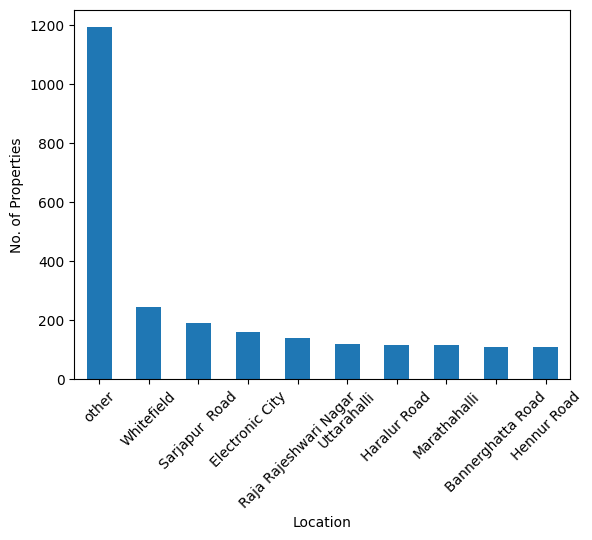

In [29]:
df_clean['location'].value_counts().head(10).plot(kind = 'bar', xlabel = 'Location', ylabel = 'No. of Properties')
plt.xticks(rotation = 45)

In [30]:
# log tranfoemation of price and price_per_sqft cols

df_clean['price_log'] = np.log1p(df_clean['price'])

df_clean['price_per_sqft'] = np.log1p(df_clean['price_per_sqft'])

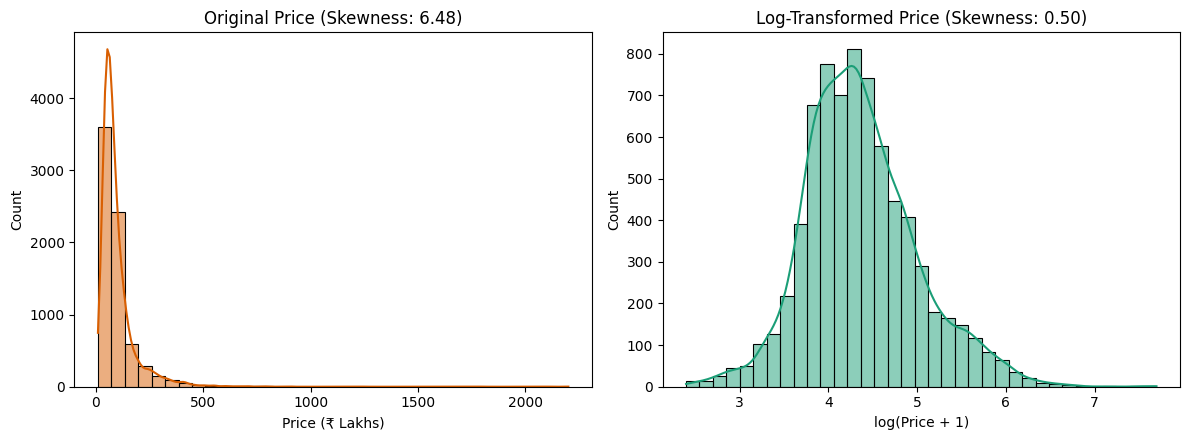

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Original Skewed Price
sns.histplot(df_clean['price'], kde=True, ax=axes[0], color='#d95f02', bins=35)
axes[0].set_title('Original Price (Skewness: 6.48)')
axes[0].set_xlabel('Price (₹ Lakhs)')

# Log-Transformed Price
sns.histplot(df_clean['price_log'], kde=True, ax=axes[1], color='#1b9e77', bins=35)
axes[1].set_title('Log-Transformed Price (Skewness: 0.50)')
axes[1].set_xlabel('log(Price + 1)')

plt.tight_layout()
plt.show()

In [32]:
# Model Building

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. One-Hot Encoding for categorical 'location'
dummies = pd.get_dummies(df_clean['location'], drop_first=True, dtype=int)
X = pd.concat([df_clean[['total_sqft', 'bath', 'size']], dummies], axis=1)
y = np.log1p(df_clean['price'])

# 2. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Benchmark
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)
    
    # Invert log predictions back to original ₹ Lakhs
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)
    
    print(f"--- {name} ---")
    print(f"R² Score: {r2_score(y_true, y_pred):.4f}")
    print(f"MAE: ₹{mean_absolute_error(y_true, y_pred):.2f} Lakhs")
    print(f"RMSE: ₹{np.sqrt(mean_squared_error(y_true, y_pred)):.2f} Lakhs\n")


--- Linear Regression ---
R² Score: 0.7666
MAE: ₹19.28 Lakhs
RMSE: ₹41.71 Lakhs

--- Ridge Regression ---
R² Score: 0.7543
MAE: ₹19.49 Lakhs
RMSE: ₹42.80 Lakhs

--- Lasso Regression ---
R² Score: 0.5633
MAE: ₹24.30 Lakhs
RMSE: ₹57.06 Lakhs

--- Random Forest ---
R² Score: 0.8571
MAE: ₹16.07 Lakhs
RMSE: ₹32.63 Lakhs

--- Gradient Boosting ---
R² Score: 0.8473
MAE: ₹17.79 Lakhs
RMSE: ₹33.74 Lakhs



In [34]:
def predict_price(location, sqft, bath, size, model, X_cols):
    loc_index = np.where(X_cols == location.lower())[0]
    
    x = np.zeros(len(X_cols))
    x[0] = sqft
    x[1] = bath
    x[2] = size
    if len(loc_index) > 0 and loc_index[0] >= 0:
        x[loc_index[0]] = 1

    # Invert log1p prediction
    pred_log = model.predict([x])[0]
    return round(np.expm1(pred_log), 2)

# Example test:
predict_price('Electronic City Phase II', 1200, 2, 2, best_model, X.columns.str.lower())

/home/ishanmohanty4/thesis_ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


np.float64(36.97)